In [69]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np 

In [70]:
df=pd.read_csv("data/train/flight_signals_dataset.csv")
df_result=pd.read_csv("data/train/train_tabular.csv")
labels=df_result["failure_within_horizon"]
df = df.merge(
    df_result[["flight_id", "failure_within_horizon"]],
    on="flight_id",
    how="left"
)
df.head(200)
# df[df["flight_id"] == 16]


,flight_id,time_step,accel_x,accel_y,accel_z,gyro_z,motor_current_1,motor_current_2,vibration,battery_voltage,failure_within_horizon
0,0,0,-0.065681,0.003845,0.088945,0.091702,0.068763,0.039613,0.037937,0.908622,0
1,0,1,-0.004804,0.036983,0.031530,-0.057574,0.082236,0.049392,0.020964,1.004656,0
2,0,2,-0.048994,-0.082252,0.034755,-0.054014,0.055887,-0.000031,0.039784,1.069685,0
3,0,3,0.020671,-0.052529,0.083901,-0.011660,-0.000663,0.000578,-0.004961,0.947578,0
4,0,4,-0.065176,0.051166,-0.012283,-0.058412,0.092972,-0.111027,-0.000654,0.991390,0
...,...,...,...,...,...,...,...,...,...,...,...
195,1,67,0.069752,0.133022,0.097720,0.170884,0.354507,0.375580,-0.026350,0.977465,0
196,1,68,0.058173,0.051074,0.075417,0.141318,0.412631,0.345155,0.023170,1.057665,0
197,1,69,0.079167,0.009087,0.138120,0.184939,0.419309,0.386730,-0.154856,0.985925,0
198,1,70,0.061291,0.021229,0.052876,0.114918,0.362628,0.409646,-0.087230,0.952804,0


In [71]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2031616 entries, 0 to 2031615
Data columns (total 11 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   flight_id               int64  
 1   time_step               int64  
 2   accel_x                 float64
 3   accel_y                 float64
 4   accel_z                 float64
 5   gyro_z                  float64
 6   motor_current_1         float64
 7   motor_current_2         float64
 8   vibration               float64
 9   battery_voltage         float64
 10  failure_within_horizon  int64  
dtypes: float64(8), int64(3)
memory usage: 170.5 MB


,flight_id,time_step,accel_x,accel_y,accel_z,gyro_z,motor_current_1,motor_current_2,vibration,battery_voltage,failure_within_horizon
count,2.031616e+06,2.031616e+06,2.031616e+06,2.031616e+06,2.031616e+06,2.031616e+06,2.031616e+06,2.031616e+06,2.031616e+06,2.031616e+06,2.031616e+06
mean,1.052411e+04,6.350000e+01,2.708065e-05,6.035174e-04,-2.980850e-04,-7.288710e-04,2.477382e-01,2.479771e-01,4.051649e-05,9.752340e-01,1.251260e-01
std,6.061526e+03,3.694930e+01,3.411449e-01,3.407777e-01,3.407054e-01,3.402394e-01,1.617285e-01,1.618319e-01,2.094548e-01,1.053014e-01,3.308618e-01
min,0.000000e+00,0.000000e+00,-4.909283e+00,-4.493163e+00,-3.911959e+00,-4.103946e+00,-3.790335e-01,-4.136871e-01,-1.256885e+00,0.000000e+00,0.000000e+00
25%,5.323750e+03,3.175000e+01,-8.039991e-02,-7.928425e-02,-7.954904e-02,-8.033541e-02,1.191805e-01,1.193519e-01,-1.093402e-01,9.447104e-01,0.000000e+00
50%,1.062450e+04,6.350000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.482030e-01,2.485596e-01,0.000000e+00,9.879346e-01,0.000000e+00
75%,1.568325e+04,9.525000e+01,7.967434e-02,8.014850e-02,7.941588e-02,7.977868e-02,3.752647e-01,3.754261e-01,1.095225e-01,1.027583e+00,0.000000e+00
max,2.103300e+04,1.270000e+02,4.345596e+00,4.399774e+00,4.281567e+00,5.225425e+00,9.256445e-01,9.598058e-01,1.245064e+00,1.275851e+00,1.000000e+00


In [72]:
flight1=df[df["flight_id"]==0]

In [73]:
print(df["flight_id"].nunique())
print(df.groupby("flight_id").size().value_counts())
print(df["flight_id"].nunique())


15872
128    15872
Name: count, dtype: int64
15872


In [74]:
df.isnull().sum()

flight_id                 0
time_step                 0
accel_x                   0
accel_y                   0
accel_z                   0
gyro_z                    0
motor_current_1           0
motor_current_2           0
vibration                 0
battery_voltage           0
failure_within_horizon    0
dtype: int64

In [75]:
def plot_generator(id):
    flight=df[df["flight_id"]==id]
    print(f"flight_id={id}")
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].scatter(flight["time_step"], flight["accel_x"])
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("Accel X")
    axes[0].set_title("Accel X")

    axes[1].scatter(flight["time_step"], flight["accel_y"])
    axes[1].set_xlabel("Time")
    axes[1].set_ylabel("Accel Y")
    axes[1].set_title("Accel Y")

    axes[2].scatter(flight["time_step"], flight["accel_z"])
    axes[2].set_xlabel("Time")
    axes[2].set_ylabel("Accel Z")
    axes[2].set_title("Accel Z")

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].scatter(flight["time_step"], flight["gyro_z"])
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("gyro_z")
    axes[0].set_title("gyro_z")

    axes[1].scatter(flight["time_step"], flight["vibration"])
    axes[1].set_xlabel("Time")
    axes[1].set_ylabel("vibration")
    axes[1].set_title("vibration")

    axes[2].scatter(flight["time_step"], flight["battery_voltage"])
    axes[2].set_xlabel("Time")
    axes[2].set_ylabel("battery_voltage")
    axes[2].set_title("battery_voltage")

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(15, 4))

    axes[0].scatter(flight["time_step"], flight["motor_current_1"])
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("motor_current_1")
    axes[0].set_title("motor_current_1")

    axes[1].scatter(flight["time_step"], flight["motor_current_2"])
    axes[1].set_xlabel("Time")
    axes[1].set_ylabel("motor_current_2")
    axes[1].set_title("motor_current_2")

    plt.tight_layout()
    plt.show()

flight_id=0


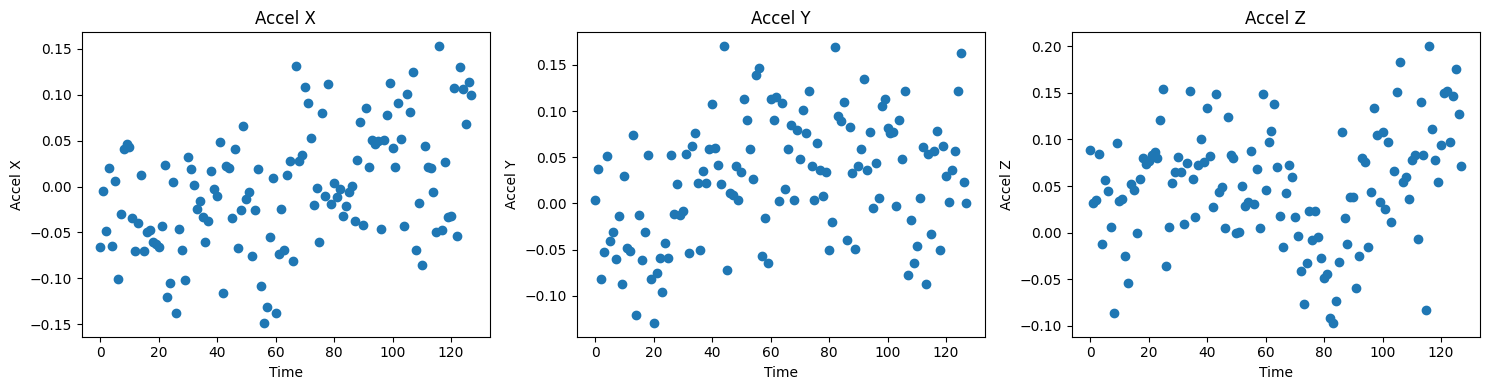

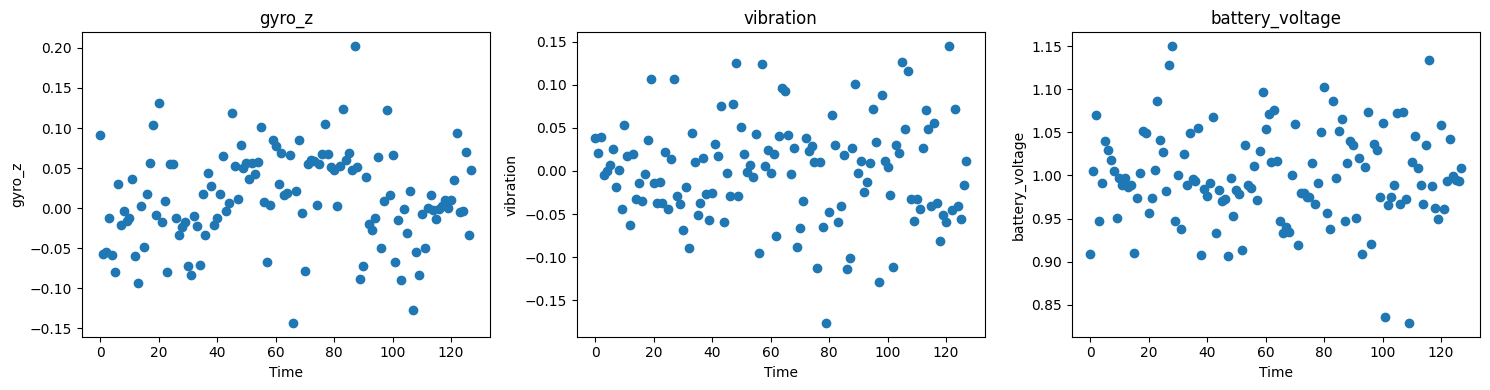

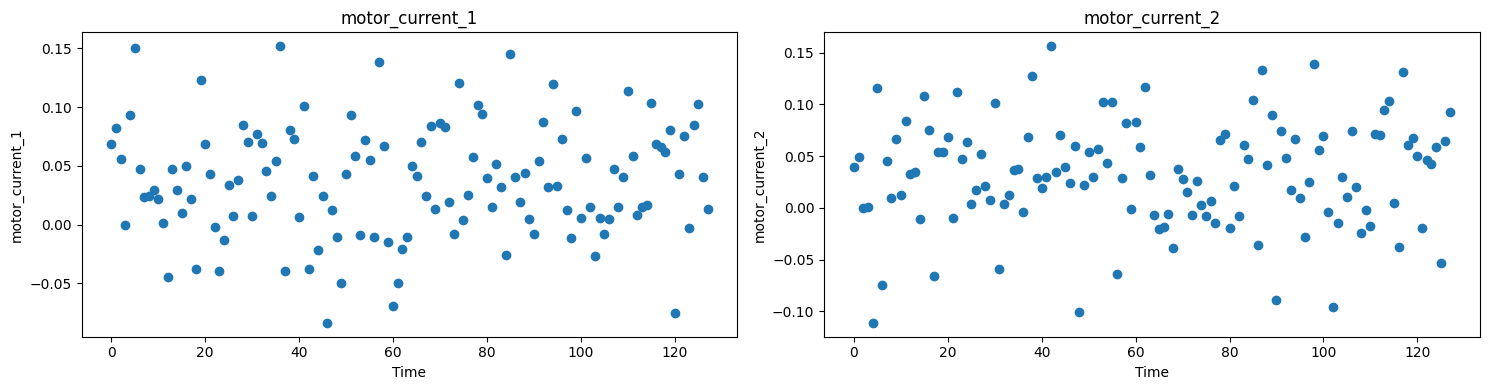

flight_id=10


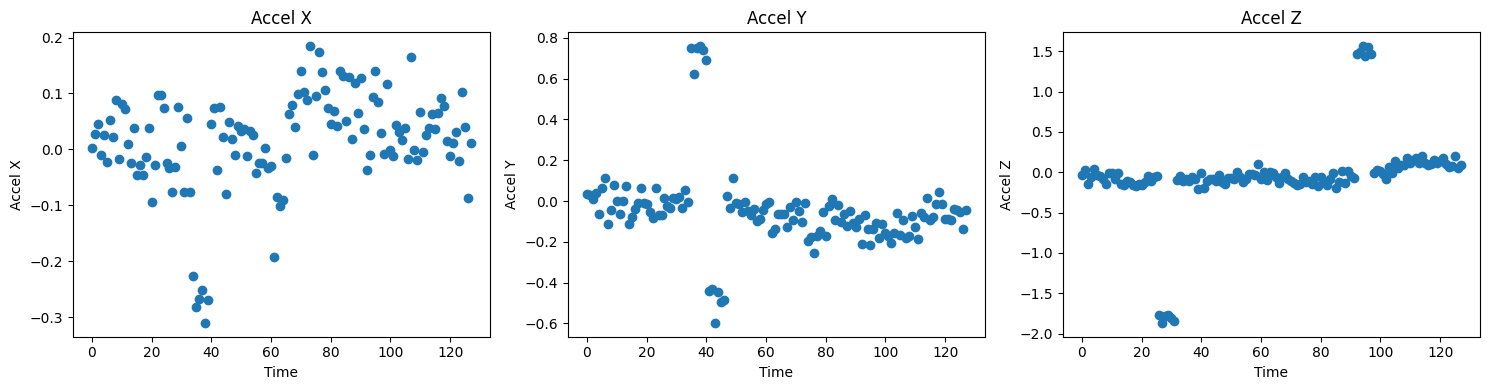

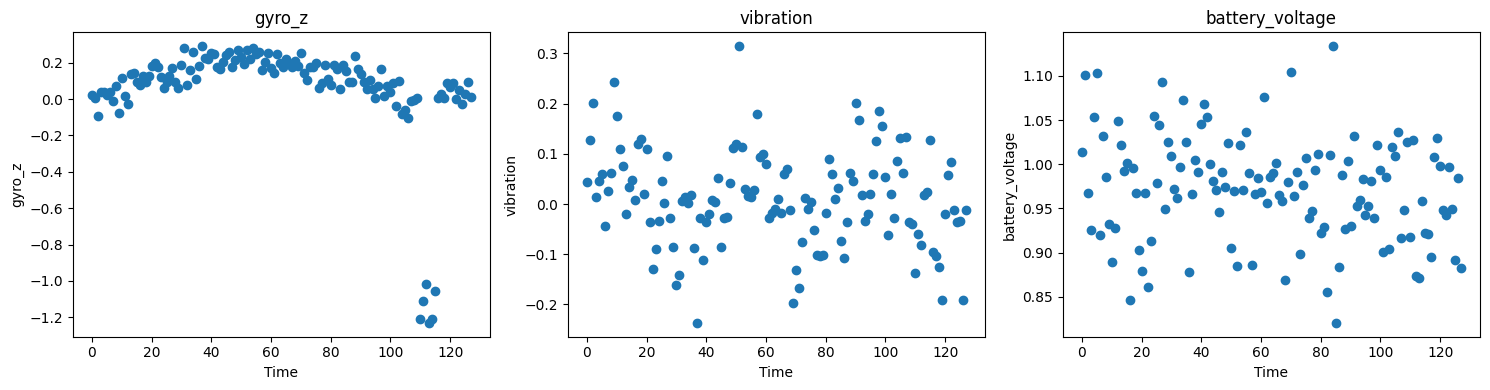

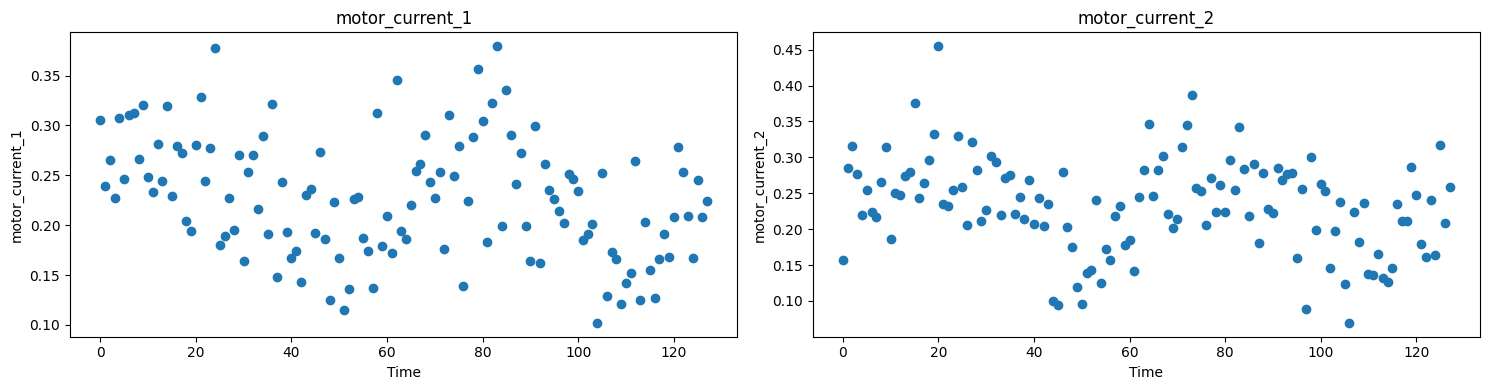

flight_id=100


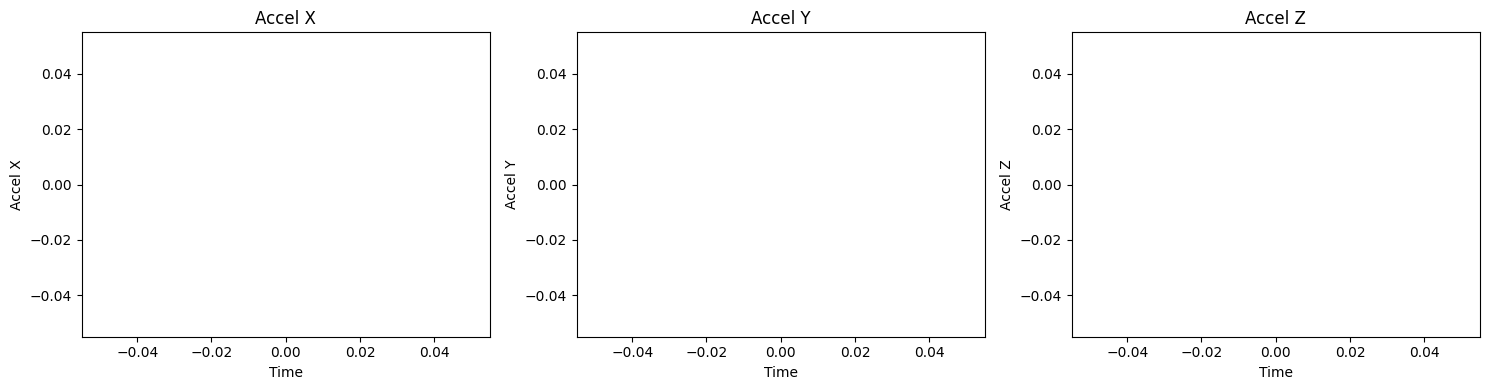

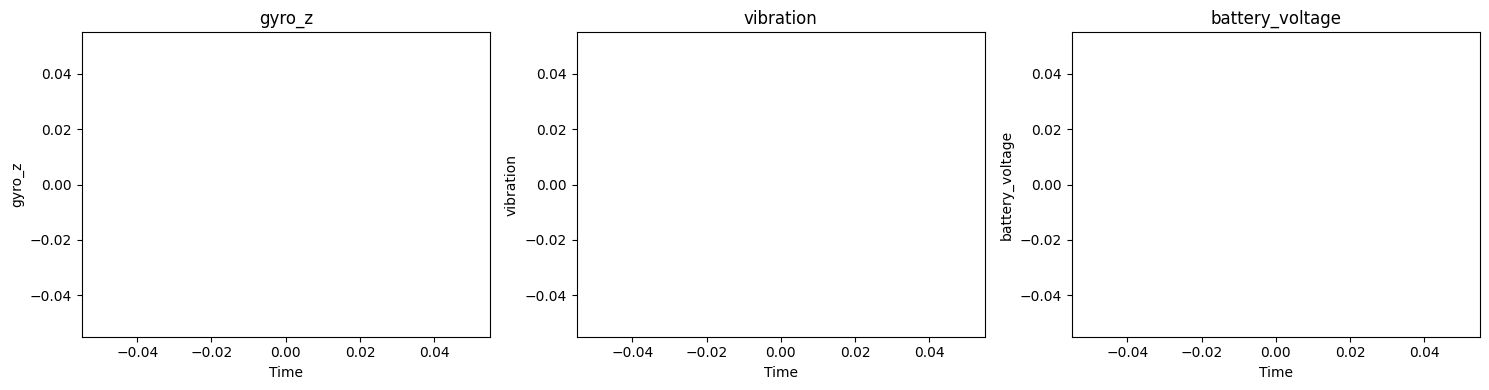

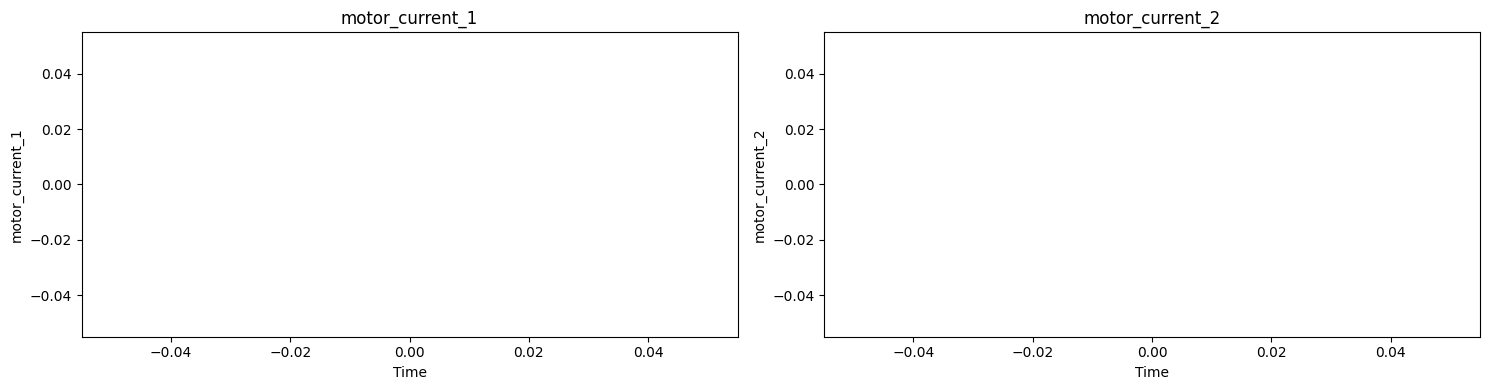

flight_id=1000


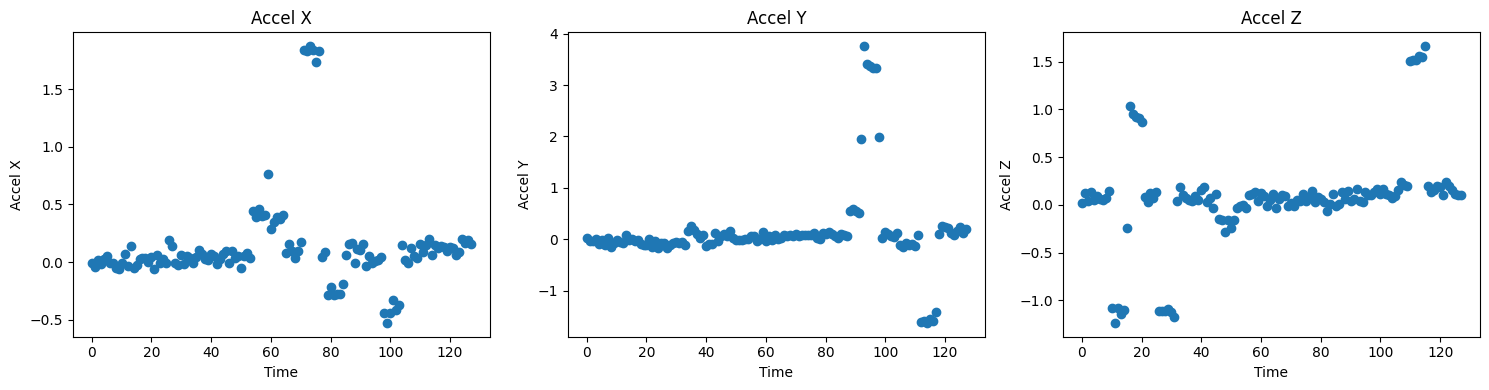

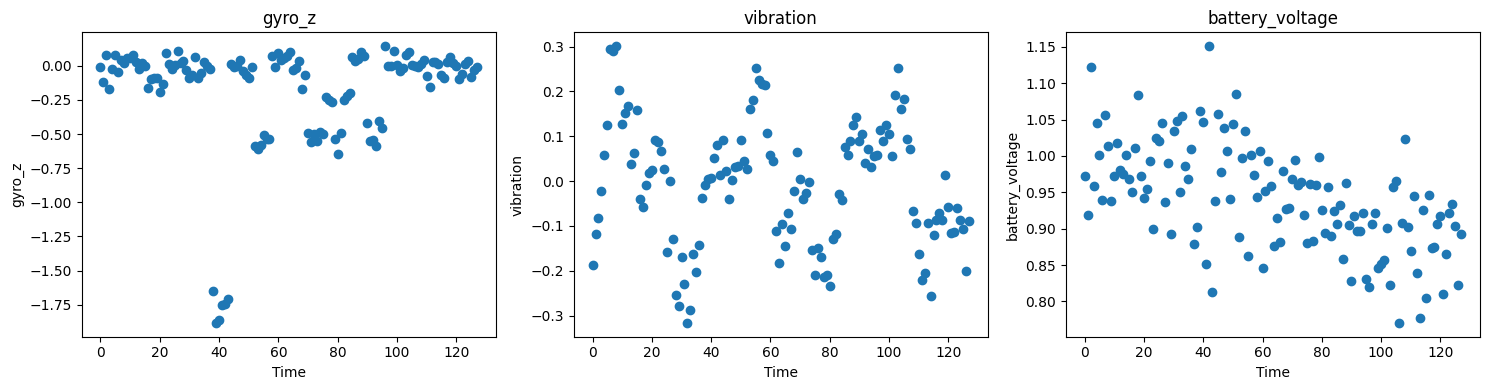

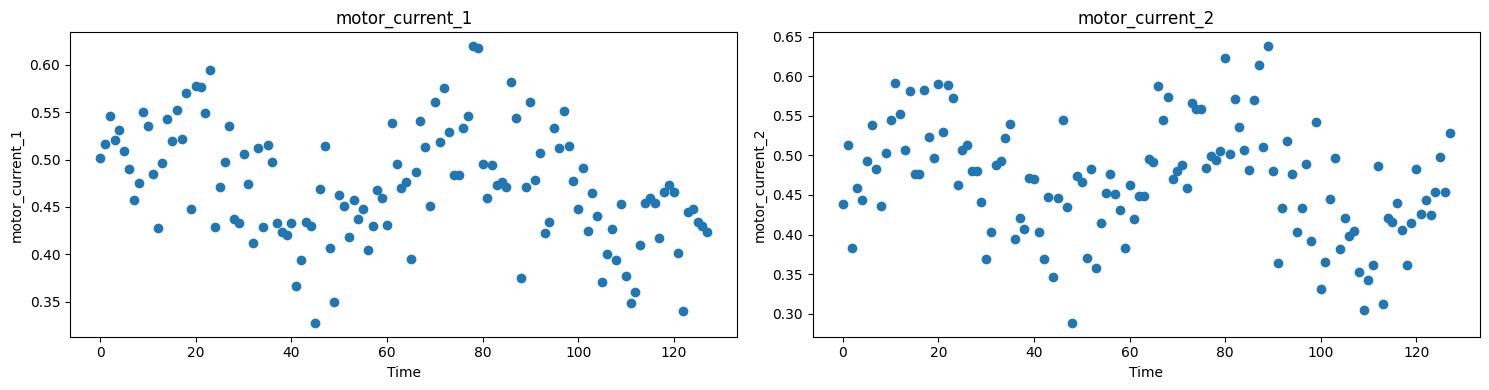

In [76]:
id=[0,10,100,1000]
for i in id:
    plot_generator(i)

flight_id=17


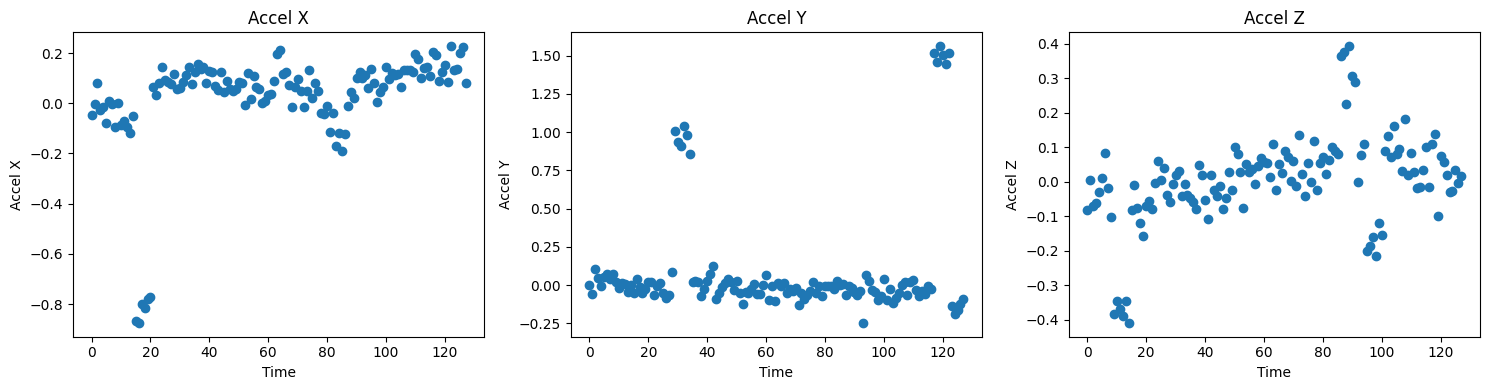

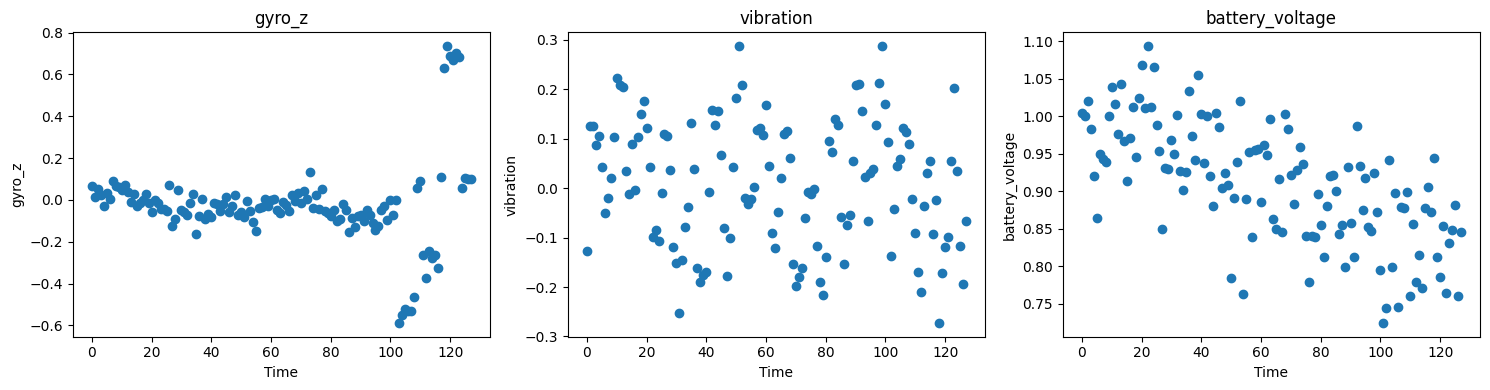

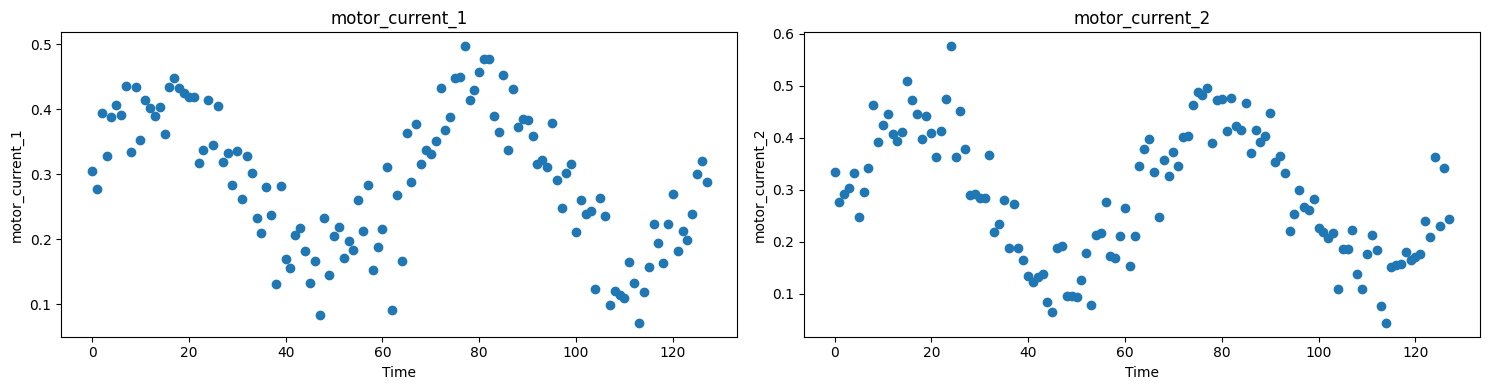

flight_id=0


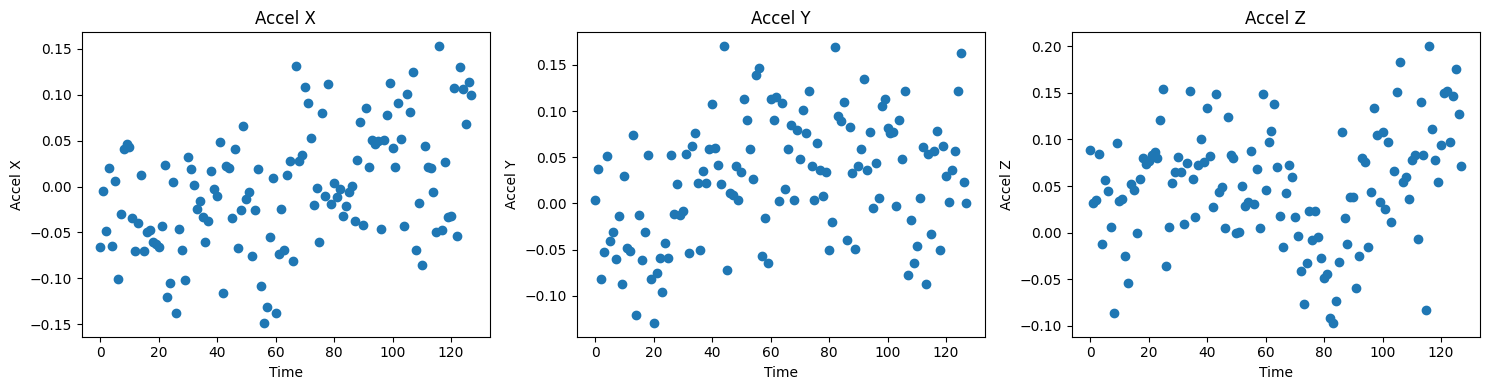

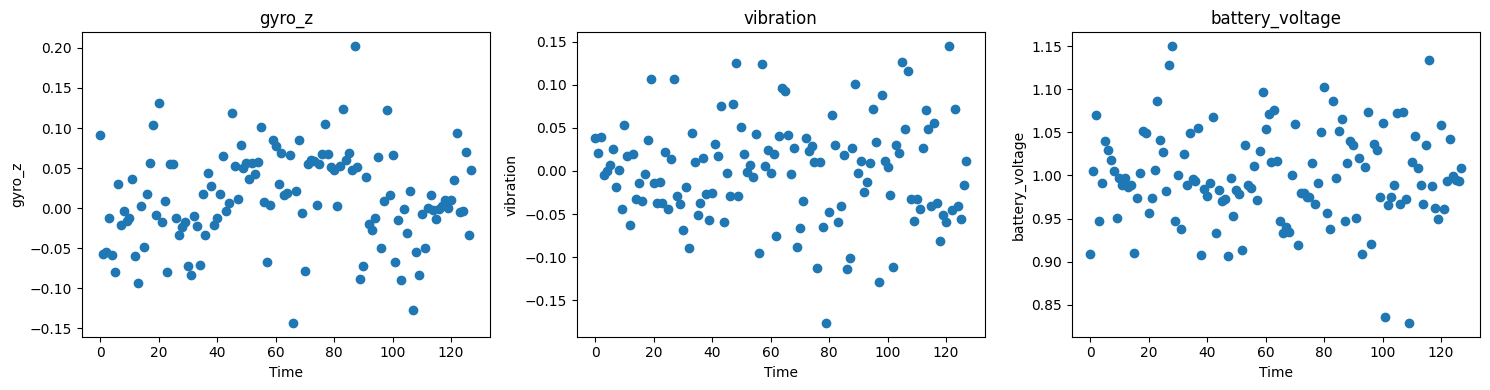

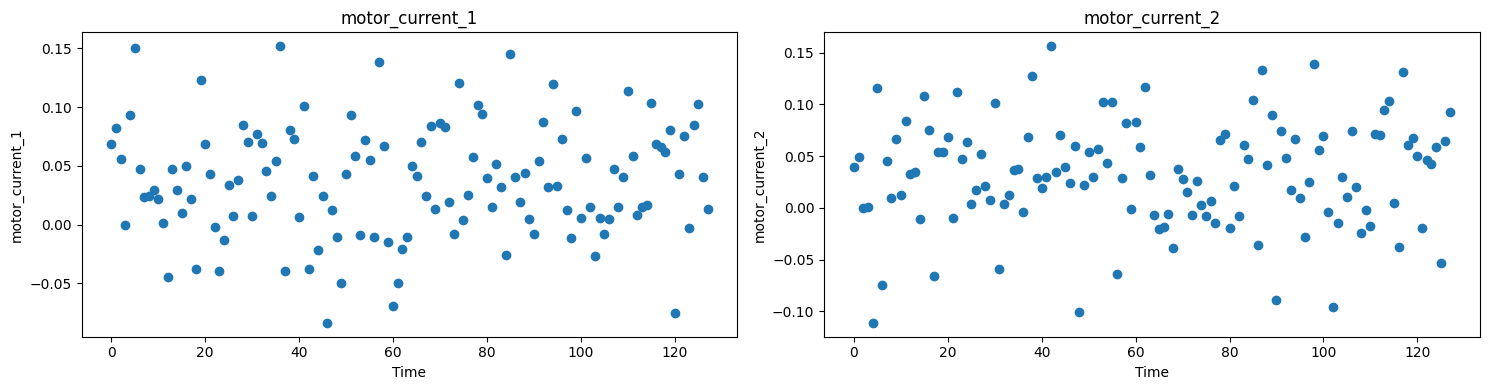

In [77]:
healthy=17
faulty=0
plot_generator(healthy)
plot_generator(faulty)


In [78]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

def stats(col, x, features):
    features[f"{col}_mean"] = np.mean(x)
    features[f"{col}_std"] = np.std(x)
    features[f"{col}_var"] = np.var(x)
    features[f"{col}_rms"] = np.sqrt(np.mean(x**2))
    features[f"{col}_min"] = np.min(x)
    features[f"{col}_max"] = np.max(x)
    features[f"{col}_median"] = np.median(x)
    features[f"{col}_skew"] = skew(x)
    features[f"{col}_kurtosis"] = kurtosis(x)

all_features = []

for flight_id in df["flight_id"].unique():

    flight = df[df["flight_id"] == flight_id] #creates a frame of subset of df corresponding to  whereflightid is desired id 

    features = {}

    # Save the flight ID
    features["flight_id"] = flight_id

    # Save the label (same for all rows of this flight)
    features["failure_within_horizon"] = flight["failure_within_horizon"].iloc[0] 
    features["drone_id"] = df_result.loc[df_result["flight_id"] == flight_id,"drone_id"].iloc[0] #first creats a boolean mask and apply on def_result["drone id"] using loc and gives a single column of all the done id we take the first row 

    for col in flight.columns:

        if col in ["flight_id", "time_step", "failure_within_horizon"]:
            continue

        x = flight[col].to_numpy()
        stats(col, x, features)

    all_features.append(features)

statistics = pd.DataFrame(all_features)

In [79]:
statistics.head(50)


,flight_id,failure_within_horizon,drone_id,accel_x_mean,accel_x_std,accel_x_var,accel_x_rms,accel_x_min,accel_x_max,accel_x_median,...,vibration_kurtosis,battery_voltage_mean,battery_voltage_std,battery_voltage_var,battery_voltage_rms,battery_voltage_min,battery_voltage_max,battery_voltage_median,battery_voltage_skew,battery_voltage_kurtosis
0,0,0,D1000,-0.003113,0.064691,0.004185,0.064765,-0.148643,0.152975,-0.006182,...,0.244374,0.998652,0.053604,0.002873,1.000089,0.828977,1.149816,0.993113,-0.025363,0.752568
1,1,0,D1000,0.120029,0.136075,0.018517,0.181448,-0.104294,0.694158,0.088490,...,-0.568503,0.996637,0.051037,0.002605,0.997942,0.878225,1.187651,0.996783,0.367886,1.023691
2,2,0,D1000,0.053043,0.216955,0.047070,0.223345,-0.167692,0.783391,-0.003016,...,-1.022931,1.001187,0.050499,0.002550,1.002460,0.875106,1.152377,0.998419,0.149473,0.207957
3,3,0,D1000,-0.051328,0.363990,0.132489,0.367591,-1.579541,1.088738,-0.091752,...,-1.100254,0.999105,0.050808,0.002581,1.000396,0.850002,1.135355,0.999793,-0.122443,-0.053000
4,4,0,D1000,-0.100770,0.181908,0.033091,0.207955,-0.915355,0.088882,-0.067879,...,-0.281223,1.002911,0.058260,0.003394,1.004602,0.868634,1.141347,1.003257,0.048934,-0.300196
5,5,0,D1000,-0.027046,0.681235,0.464081,0.681771,-2.401738,1.798971,-0.044614,...,-1.071761,1.008686,0.055116,0.003038,1.010191,0.840621,1.137598,1.010304,-0.005159,-0.095761
6,6,0,D1000,0.193890,0.359282,0.129083,0.408260,-0.091672,1.730155,0.105771,...,-0.188928,1.003925,0.057983,0.003362,1.005598,0.846984,1.150865,1.007789,-0.082370,-0.176307
7,7,0,D1000,0.005127,0.146441,0.021445,0.146531,-0.471407,0.249888,0.027381,...,-0.504067,0.995135,0.056284,0.003168,0.996726,0.787427,1.173756,0.997306,-0.136011,1.059525
8,8,1,D1000,0.117357,0.109556,0.012002,0.160546,-0.154564,0.363700,0.132354,...,-0.514325,0.976365,0.054163,0.002934,0.977866,0.864612,1.098553,0.973855,0.196549,-0.761667
9,9,0,D1000,-0.116147,0.238393,0.056831,0.265181,-0.920619,0.175308,-0.049965,...,-0.901640,0.974853,0.049559,0.002456,0.976112,0.834026,1.089178,0.966741,0.166598,-0.195777


In [80]:
statistics.info()
statistics.describe()

<class 'pandas.DataFrame'>
RangeIndex: 15872 entries, 0 to 15871
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   flight_id                 15872 non-null  int64  
 1   failure_within_horizon    15872 non-null  int64  
 2   drone_id                  15872 non-null  str    
 3   accel_x_mean              15872 non-null  float64
 4   accel_x_std               15872 non-null  float64
 5   accel_x_var               15872 non-null  float64
 6   accel_x_rms               15872 non-null  float64
 7   accel_x_min               15872 non-null  float64
 8   accel_x_max               15872 non-null  float64
 9   accel_x_median            15872 non-null  float64
 10  accel_x_skew              15872 non-null  float64
 11  accel_x_kurtosis          15872 non-null  float64
 12  accel_y_mean              15872 non-null  float64
 13  accel_y_std               15872 non-null  float64
 14  accel_y_var      

,flight_id,failure_within_horizon,accel_x_mean,accel_x_std,accel_x_var,accel_x_rms,accel_x_min,accel_x_max,accel_x_median,accel_x_skew,...,vibration_kurtosis,battery_voltage_mean,battery_voltage_std,battery_voltage_var,battery_voltage_rms,battery_voltage_min,battery_voltage_max,battery_voltage_median,battery_voltage_skew,battery_voltage_kurtosis
count,15872.000000,15872.000000,15872.000000,15872.000000,15872.000000,15872.000000,15872.000000,15872.000000,15872.000000,15872.000000,...,15872.000000,15872.000000,15872.000000,15872.000000,15872.000000,15872.000000,15872.000000,15872.000000,15872.000000,15872.000000
mean,10524.108871,0.125126,0.000027,0.290110,0.105206,0.308696,-0.828837,0.833316,-0.000004,0.002268,...,-0.829089,0.975234,0.067185,0.007835,0.979789,0.811026,1.130357,0.980272,-0.028310,-0.102611
std,6061.715455,0.330872,0.105709,0.145065,0.099099,0.145216,0.608391,0.612087,0.081298,2.229818,...,0.445535,0.057037,0.057635,0.026790,0.046725,0.149262,0.029196,0.045096,0.282906,0.440367
min,0.000000,0.000000,-0.467827,0.044277,0.001960,0.044343,-4.909283,-0.014909,-0.361923,-8.393377,...,-1.510095,0.442820,0.041667,0.001736,0.537342,0.000000,0.865033,0.553270,-1.834622,-1.366211
25%,5323.750000,0.000000,-0.070916,0.178934,0.032018,0.198258,-1.221276,0.287110,-0.052448,-1.935918,...,-1.205302,0.982440,0.052023,0.002706,0.983964,0.822264,1.113951,0.983030,-0.144539,-0.393377
50%,10624.500000,0.000000,-0.000571,0.279290,0.078003,0.295676,-0.738210,0.739577,0.000000,0.002263,...,-0.851912,0.996819,0.054671,0.002989,0.998261,0.852373,1.130788,0.996316,-0.003474,-0.146742
75%,15683.250000,0.000000,0.070177,0.385064,0.148274,0.403029,-0.289941,1.222798,0.052452,1.935556,...,-0.550255,1.001402,0.058168,0.003384,1.002829,0.870480,1.148362,1.001872,0.130686,0.137684
max,21033.000000,1.000000,0.483871,1.018939,1.038236,1.054631,0.035327,4.345596,0.392596,7.994499,...,2.493817,1.016106,0.467702,0.218745,1.017612,0.923527,1.275851,1.022797,0.877014,2.720952


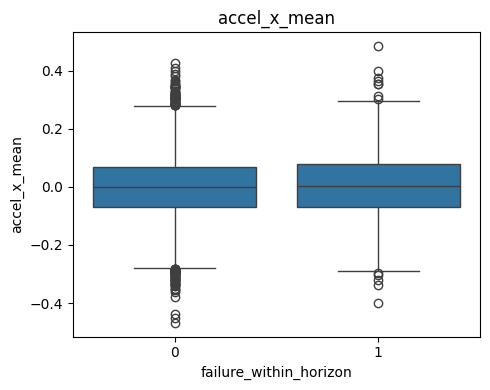

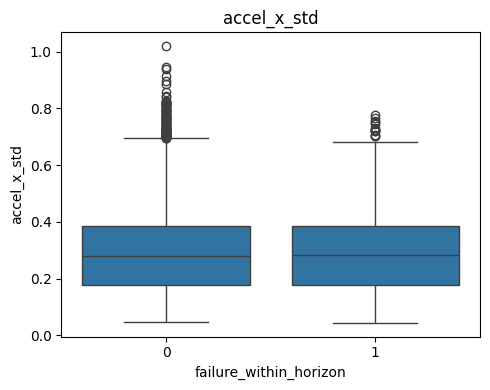

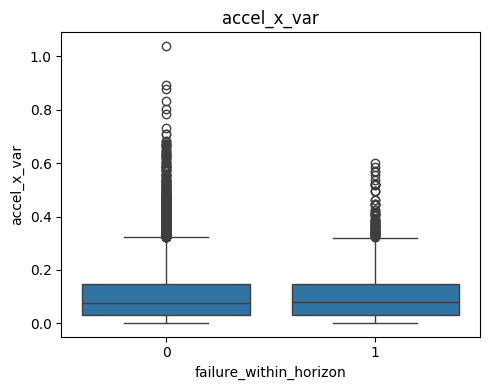

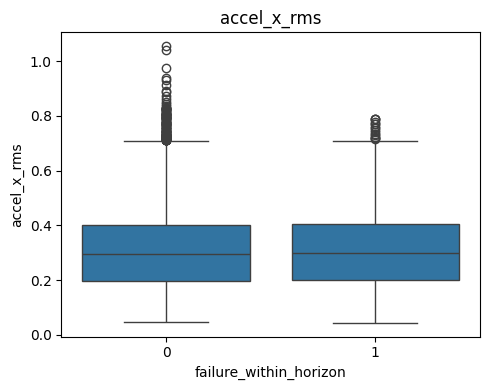

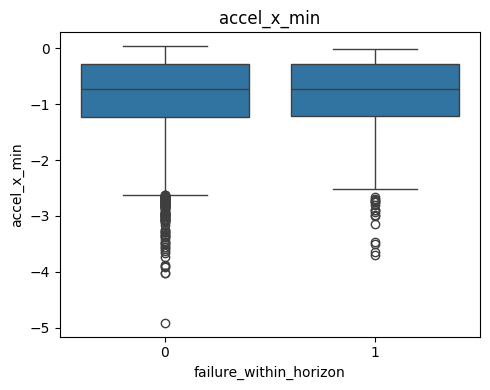

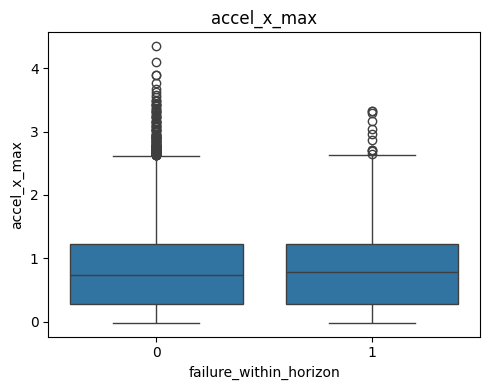

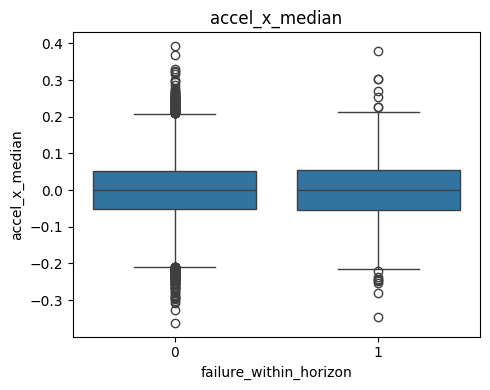

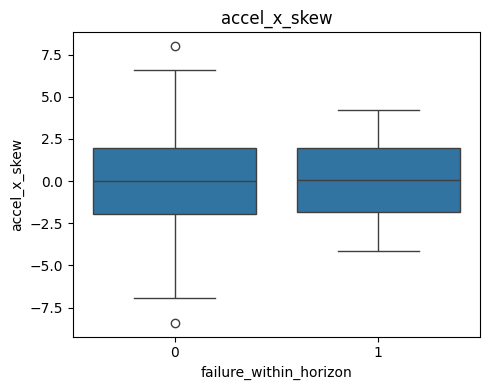

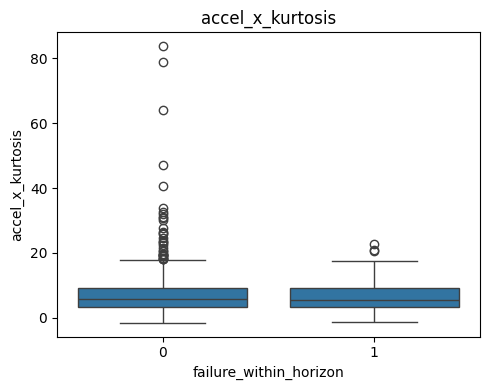

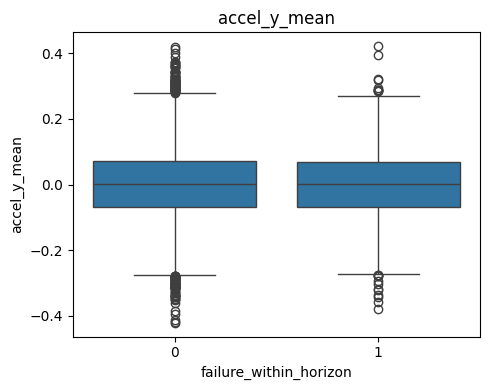

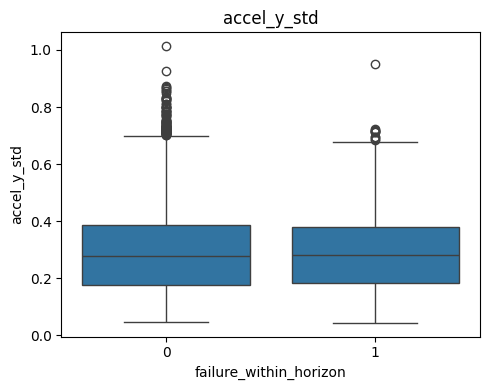

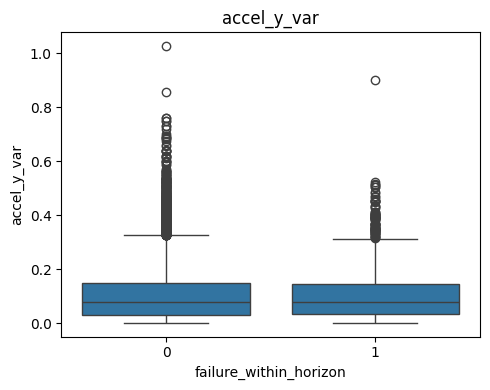

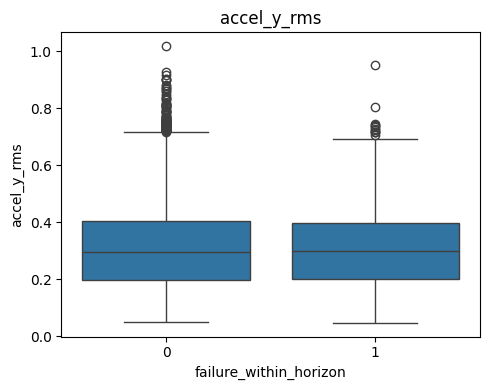

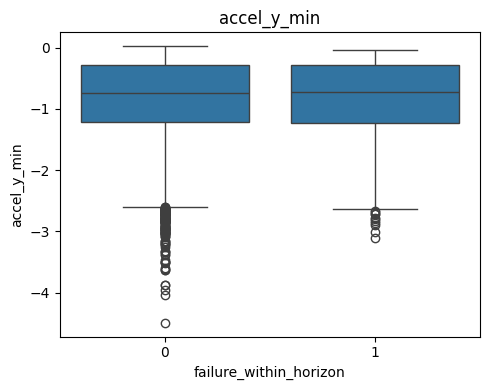

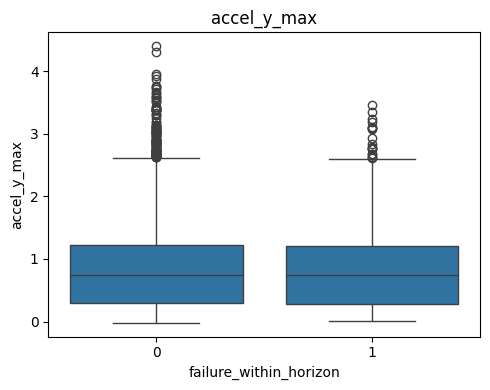

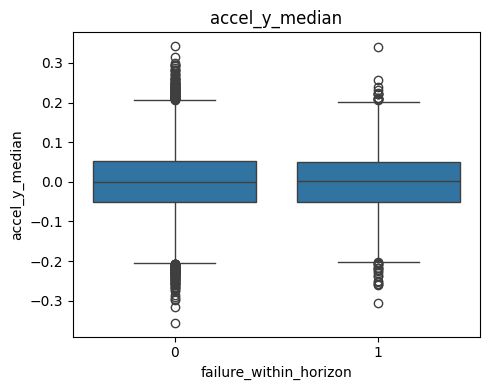

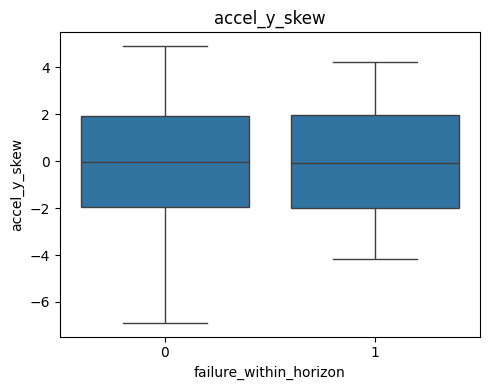

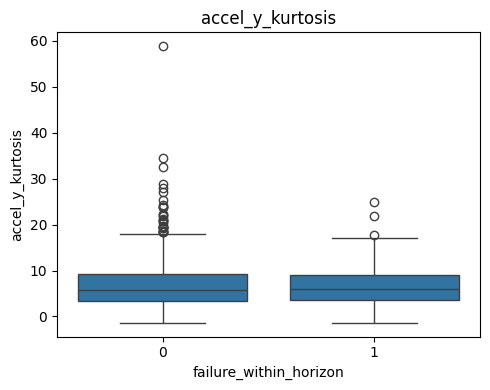

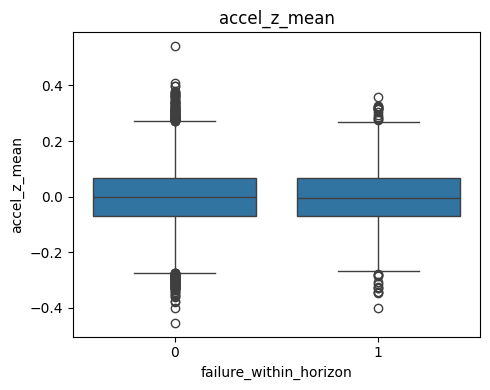

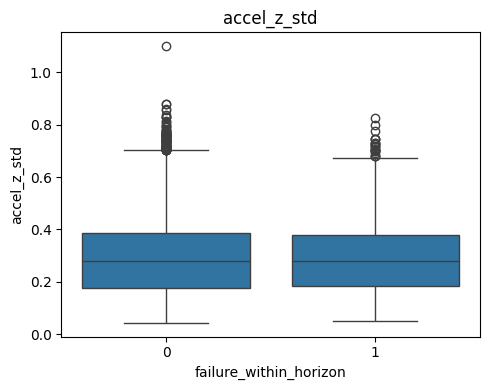

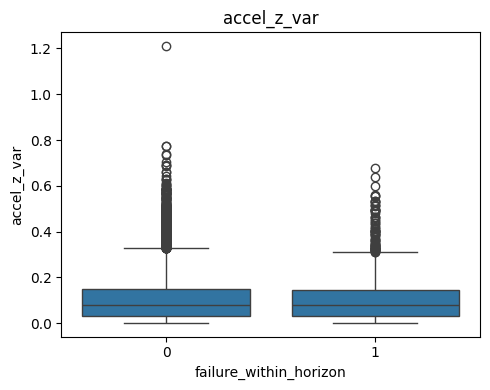

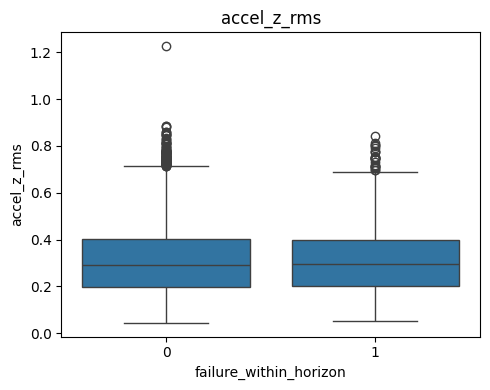

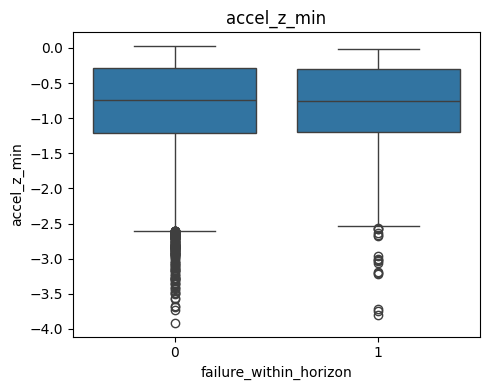

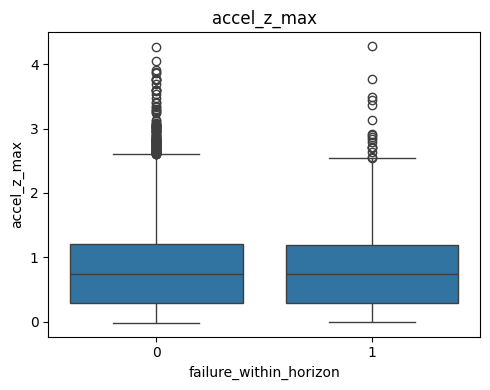

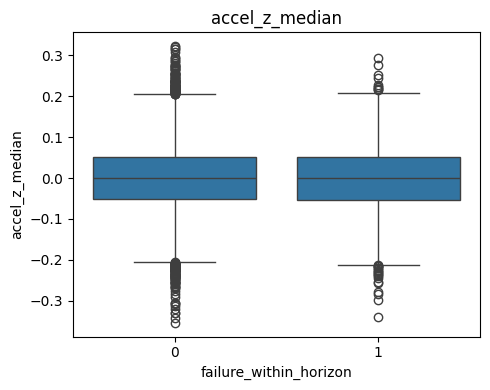

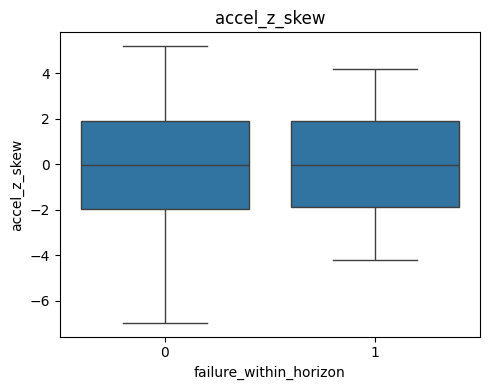

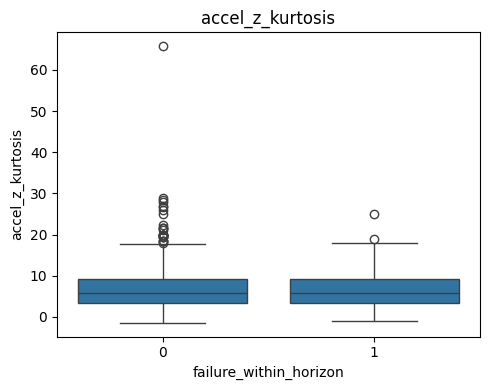

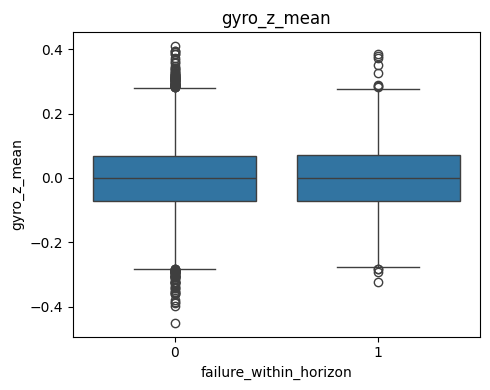

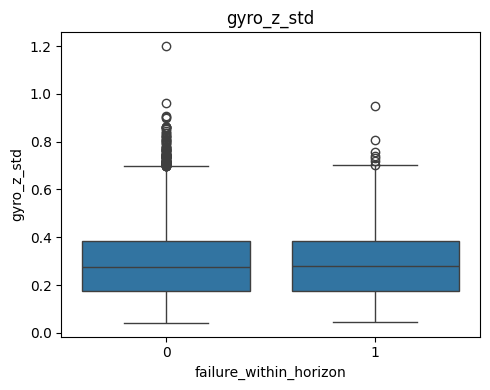

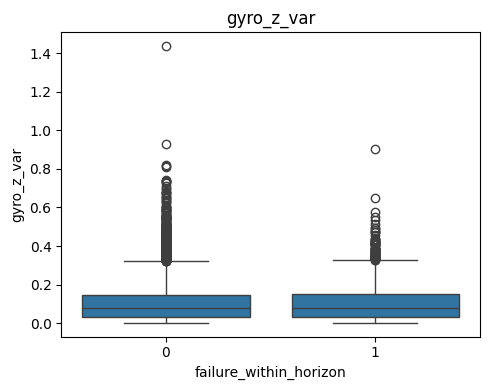

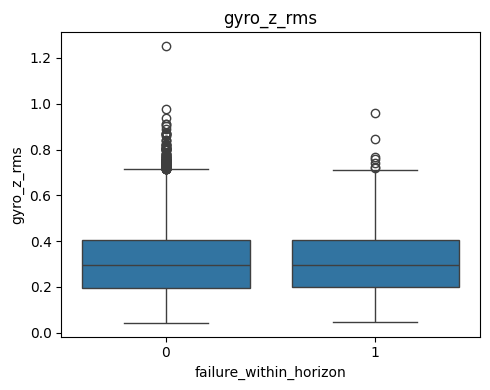

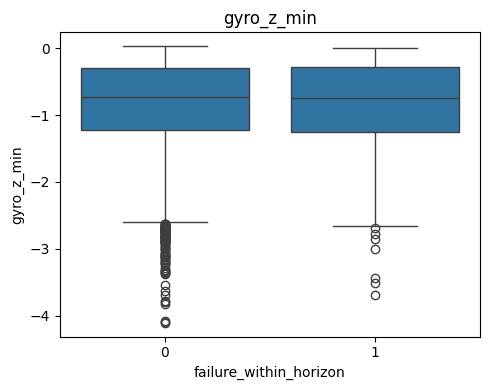

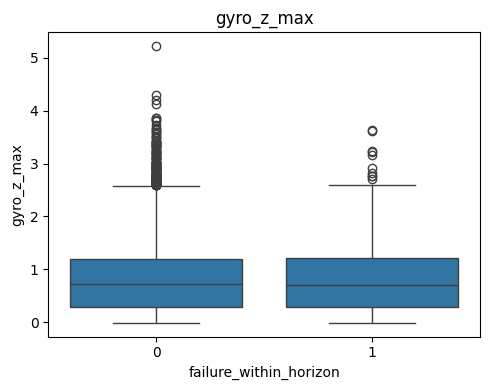

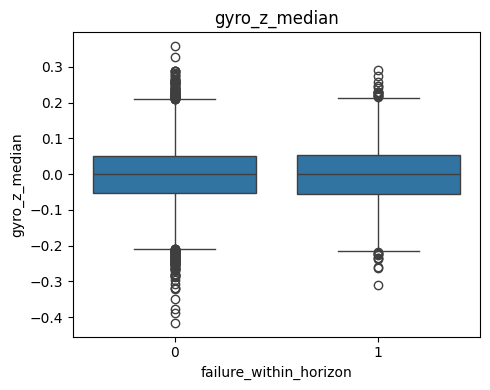

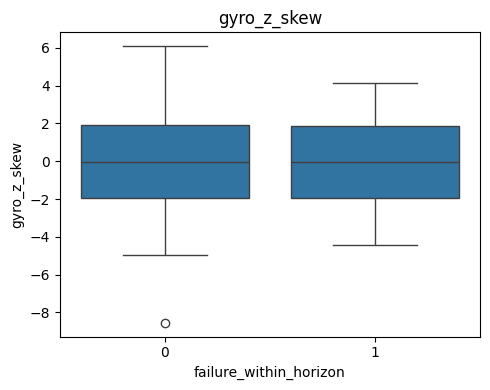

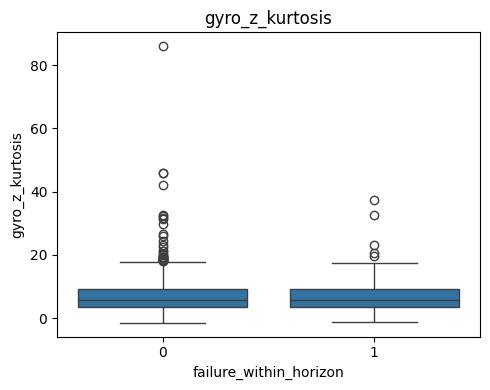

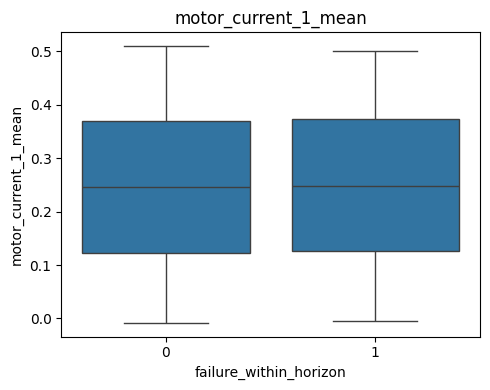

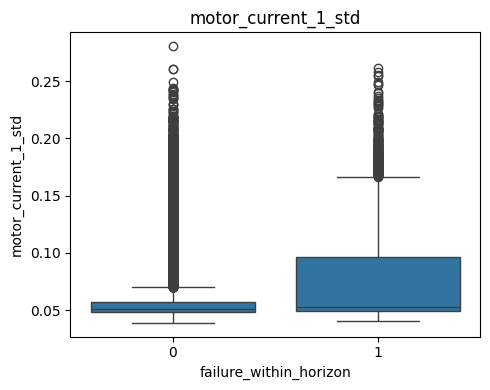

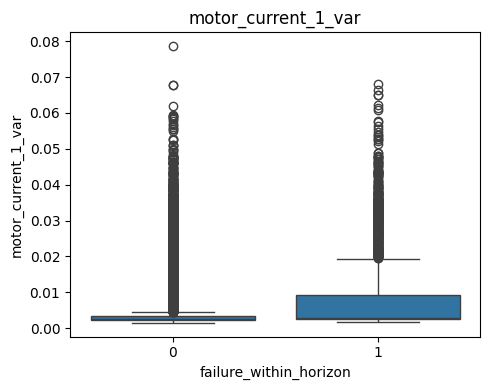

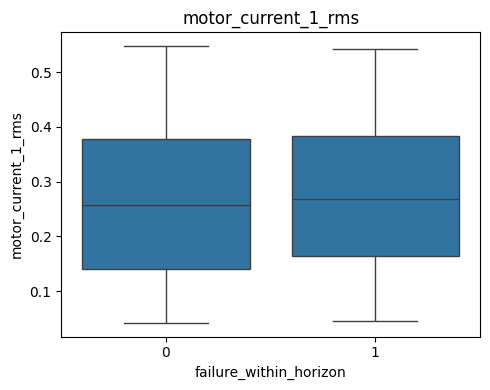

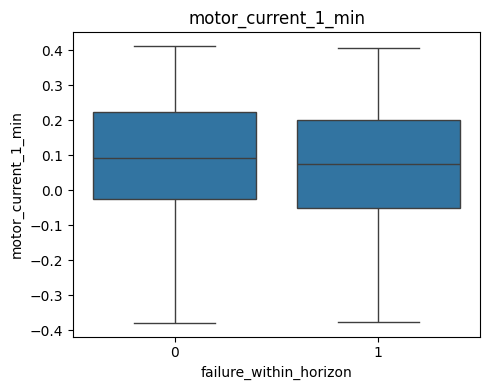

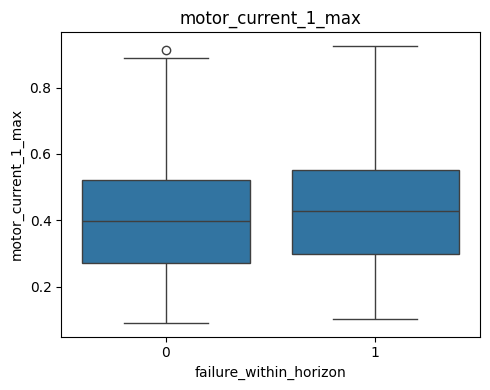

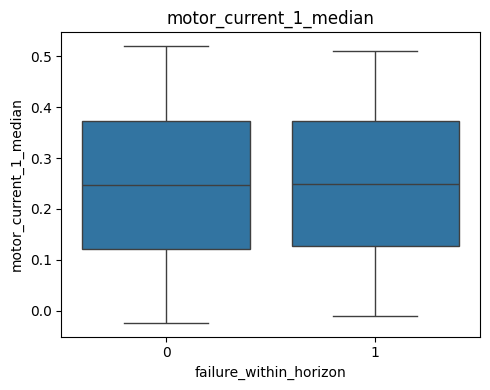

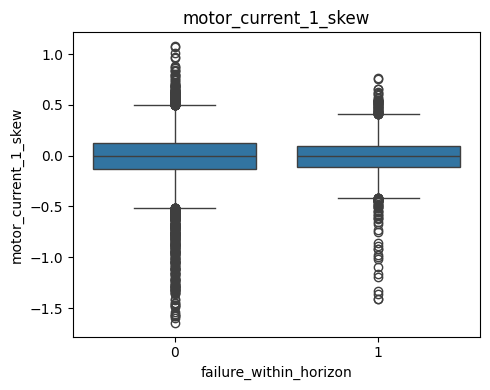

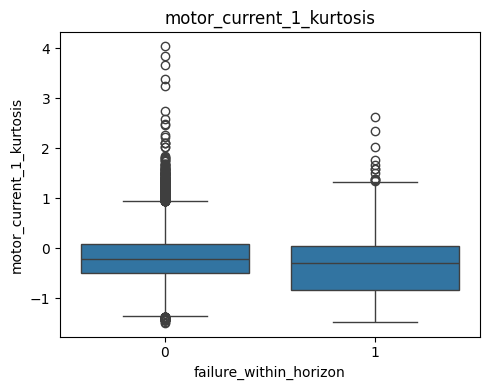

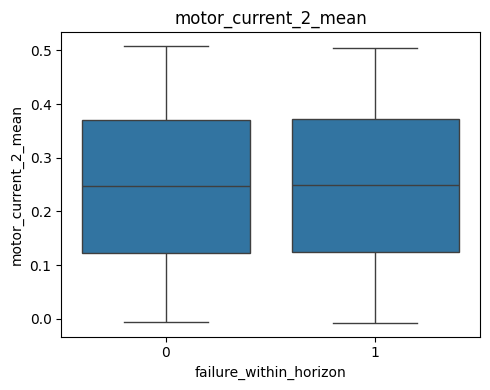

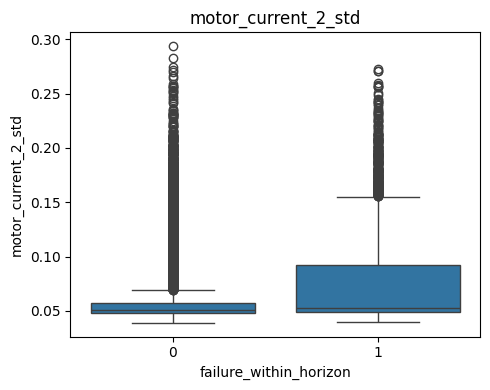

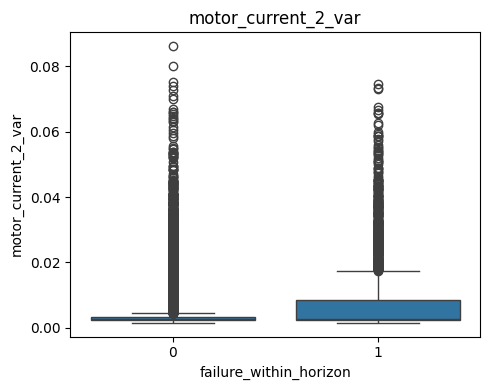

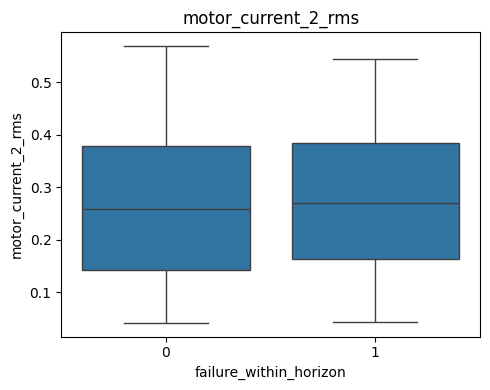

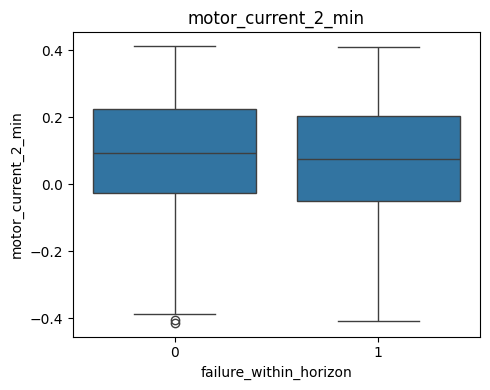

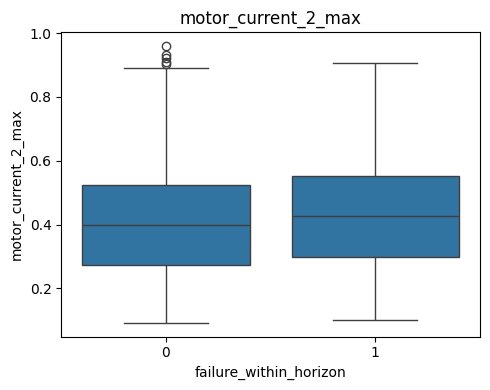

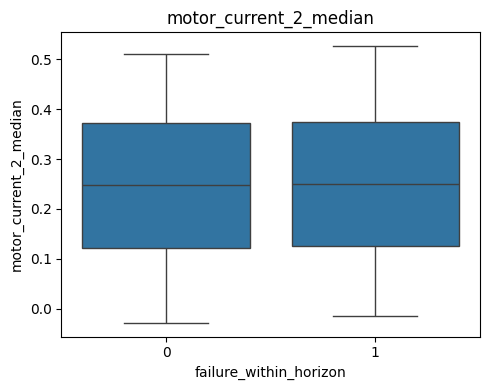

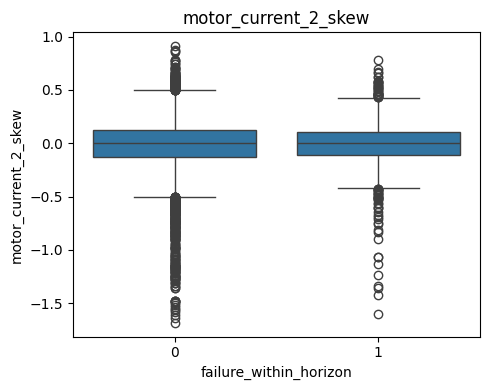

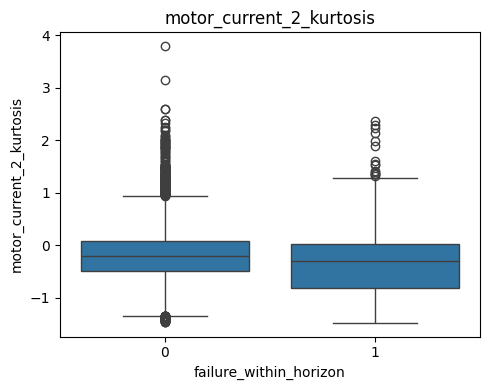

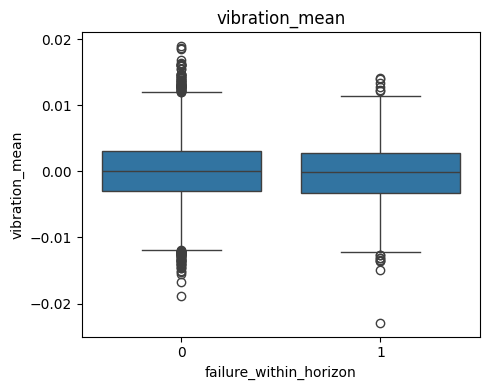

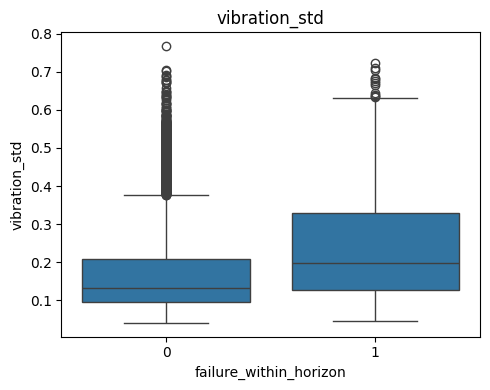

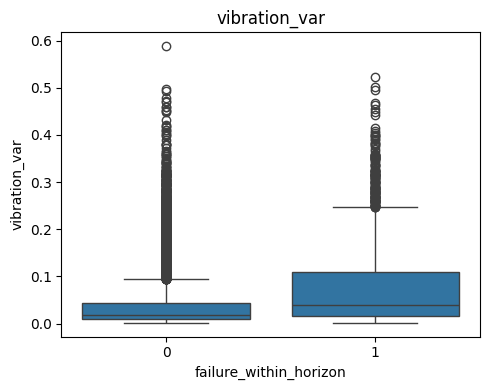

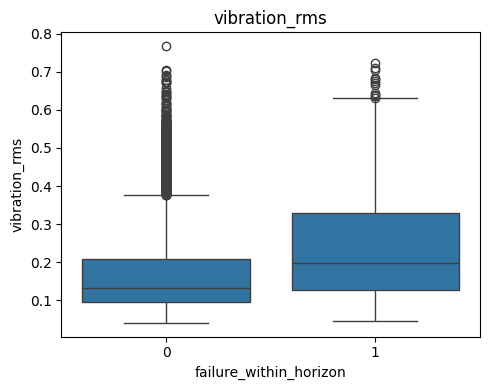

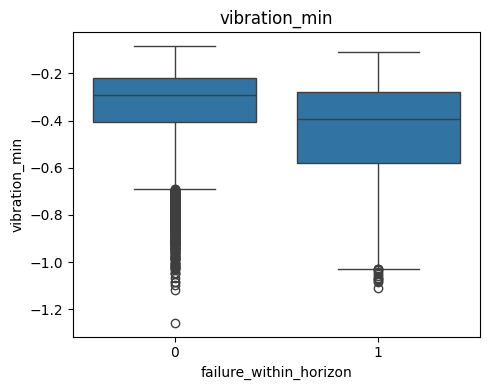

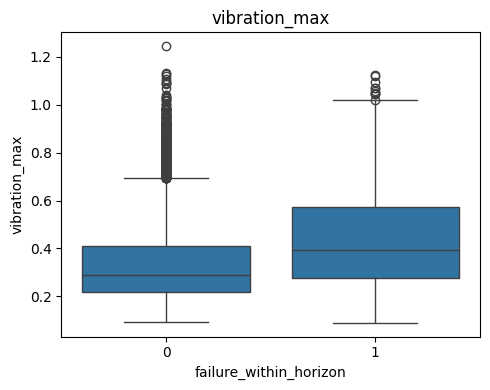

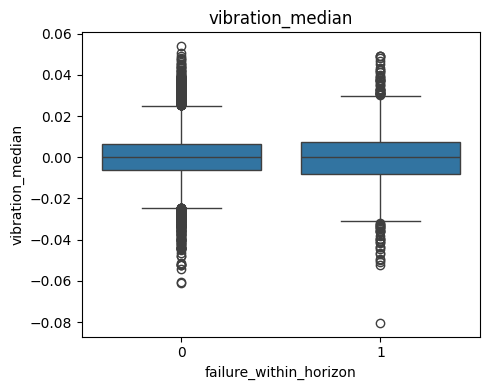

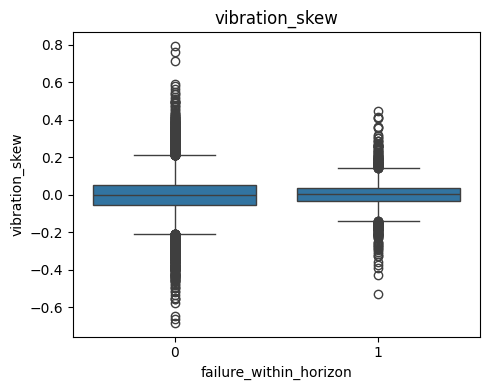

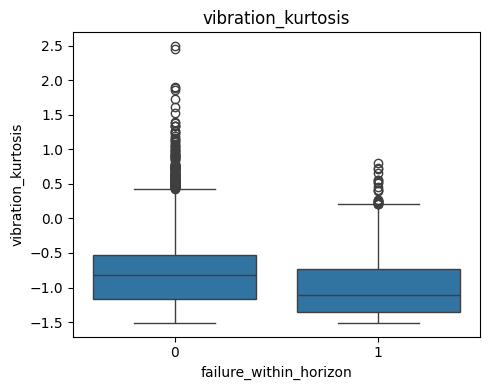

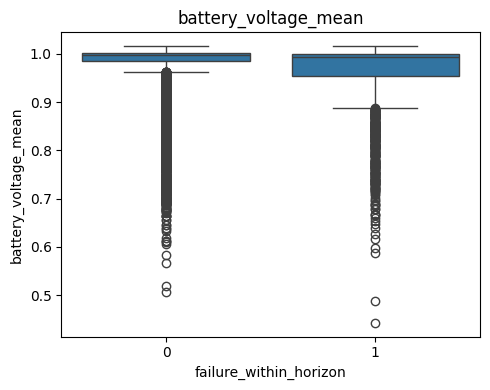

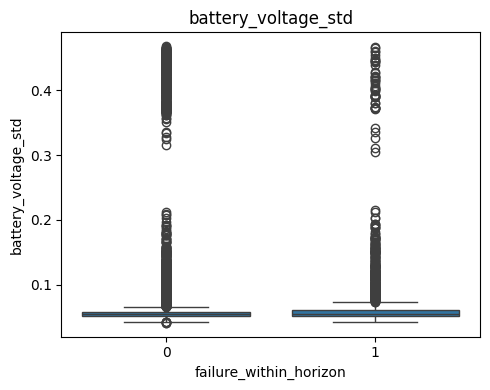

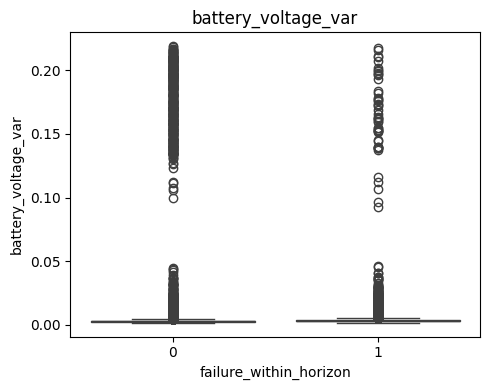

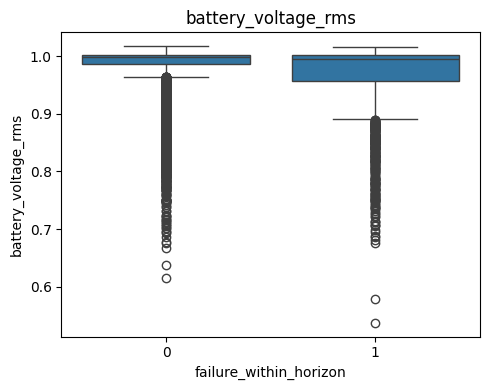

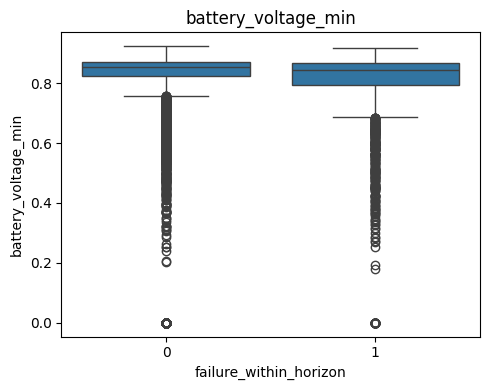

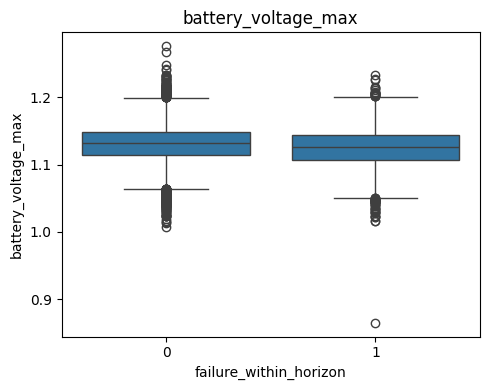

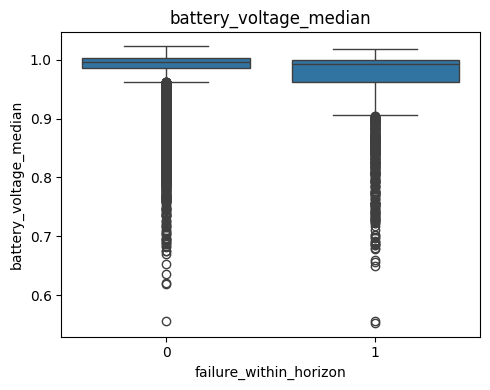

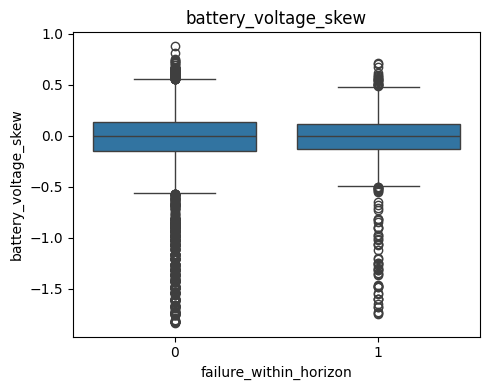

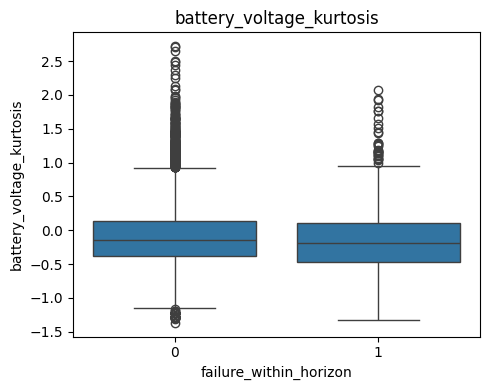

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in statistics.columns:
    if col in ["flight_id", "drone_id", "failure_within_horizon"]:
        continue

    plt.figure(figsize=(5, 4))

    sns.boxplot(
        data=statistics,
        x="failure_within_horizon",
        y=col
    )

    plt.title(col)
    plt.tight_layout()
    plt.show()

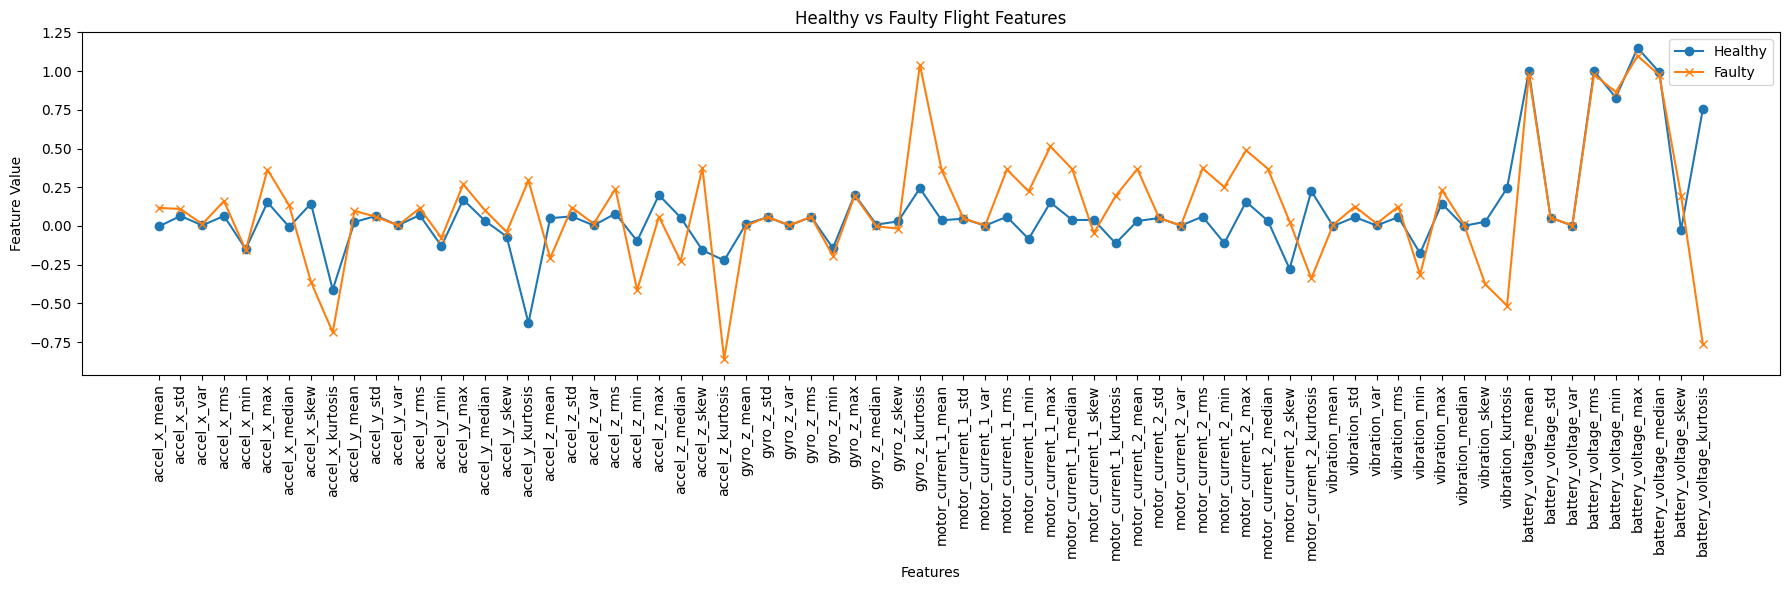

In [82]:
feature_cols = statistics.columns.drop(["flight_id", "failure_within_horizon","drone_id"]) # column names 
healthy = statistics[statistics["failure_within_horizon"] == 0].iloc[0]
faulty = statistics[statistics["failure_within_horizon"] == 1].iloc[0]


import matplotlib.pyplot as plt

plt.figure(figsize=(18,6))

plt.plot(feature_cols, healthy[feature_cols], marker='o', label='Healthy')
plt.plot(feature_cols, faulty[feature_cols], marker='x', label='Faulty')

plt.xticks(rotation=90)
plt.xlabel("Features")
plt.ylabel("Feature Value")
plt.title("Healthy vs Faulty Flight Features")
plt.legend()

plt.tight_layout()
plt.show()

In [83]:
from sklearn.preprocessing import StandardScaler
X=statistics.drop(columns=["flight_id","failure_within_horizon","drone_id"])
X_scaled = StandardScaler().fit_transform(X)


In [84]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, GroupKFold
gkf=GroupKFold(n_splits=6)
groups = statistics["drone_id"]
lr=LogisticRegression(max_iter=1000,
    random_state=42)
scores = cross_val_score(
    lr,
    X_scaled,
    statistics["failure_within_horizon"],
    cv=gkf,
    groups=groups,
    scoring="average_precision"
)
print("Fold scores:", scores)
print("Mean AUPRC:", scores.mean())

Fold scores: [0.33881277 0.30525407 0.27511347 0.28019782 0.26064525 0.27095518]
Mean AUPRC: 0.28849642663684133


In [85]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_scaled, statistics["failure_within_horizon"])

coef = pd.Series(
    lr.coef_[0],
    index=X.columns
)

print(coef.sort_values(ascending=False).head(10))
print(coef.sort_values().head(10))

motor_current_1_rms       1.073711
vibration_rms             0.745530
vibration_std             0.743996
battery_voltage_median    0.425909
motor_current_1_var       0.364328
motor_current_1_max       0.327877
accel_x_mean              0.311262
accel_y_std               0.289802
motor_current_1_mean      0.243792
motor_current_2_max       0.227150
dtype: float64
motor_current_1_median   -0.668494
vibration_var            -0.536283
motor_current_2_median   -0.511241
battery_voltage_rms      -0.488995
battery_voltage_var      -0.355325
motor_current_1_min      -0.342060
motor_current_1_std      -0.320771
motor_current_2_min      -0.299886
motor_current_2_mean     -0.295006
gyro_z_std               -0.262370
dtype: float64


In [86]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import average_precision_score

dt=DecisionTreeClassifier(random_state=42)
scores = cross_val_score(
    dt,
    X_scaled,
    statistics["failure_within_horizon"],
    cv=gkf,
    groups=groups,
    scoring="average_precision"
)
print("Fold scores:", scores)
print("Mean AUPRC:", scores.mean())


Fold scores: [0.15382095 0.15368517 0.13144566 0.13734876 0.14072683 0.13659456]
Mean AUPRC: 0.14227032001217937


In [87]:
from sklearn.ensemble import RandomForestClassifier
gkf = GroupKFold(n_splits=6)

groups = statistics["drone_id"]   

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

scores = cross_val_score(
    rf,
    X_scaled,
    statistics["failure_within_horizon"],
    cv=gkf,
    groups=groups,
    scoring="average_precision"
)

print("Fold scores:", scores)
print("Mean AUPRC:", scores.mean())

Fold scores: [0.35259402 0.29648616 0.24845903 0.2773281  0.2541808  0.27972639]
Mean AUPRC: 0.284795749972292


WHAT IS IMPORTANCE 
for a decision tree contributions is beasically the some of (reduction in gini impurity at evry node that its used) and in random forest we take average of all importances which is then normalized and gives us the final importance score of that feature 

In [88]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_scaled, statistics["failure_within_horizon"])

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance.head(20))

motor_current_1_std         0.023665
vibration_rms               0.023009
motor_current_1_var         0.022622
vibration_std               0.021338
vibration_var               0.020429
vibration_max               0.019763
motor_current_2_kurtosis    0.019662
motor_current_2_var         0.019484
motor_current_1_kurtosis    0.019042
vibration_kurtosis          0.019041
vibration_min               0.018902
motor_current_2_std         0.017998
battery_voltage_median      0.017342
battery_voltage_rms         0.015485
motor_current_1_skew        0.015462
vibration_median            0.015344
battery_voltage_mean        0.015023
vibration_mean              0.014828
gyro_z_median               0.014787
battery_voltage_kurtosis    0.014632
dtype: float64


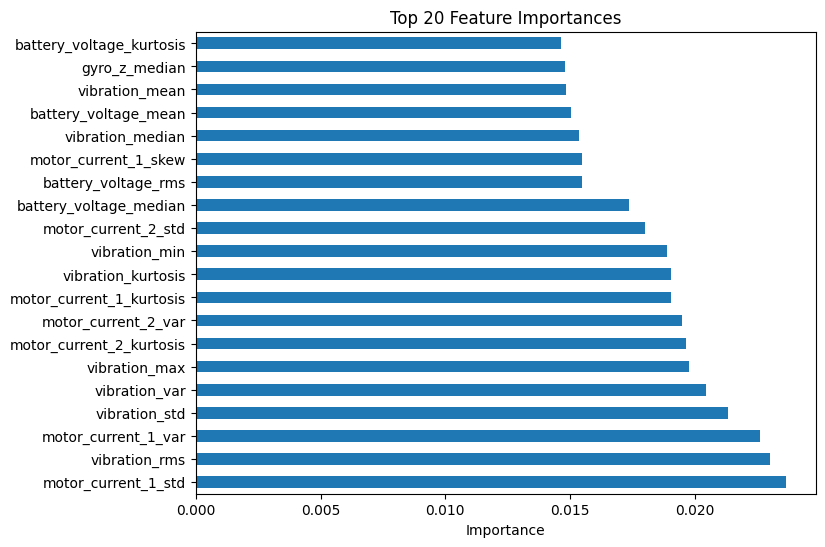

In [89]:
import matplotlib.pyplot as plt

importance.head(20).plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.show()

In [90]:
from xgboost import XGBClassifier

groups = statistics["drone_id"]


gkf = GroupKFold(n_splits=6)

# XGBoost model
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

scores = cross_val_score(
    xgb,
    X_scaled,
    statistics["failure_within_horizon"],
    cv=gkf,
    groups=groups,
    scoring="average_precision"      
)

print("Fold scores:", scores)
print("Mean score:", scores.mean())

Fold scores: [0.34278418 0.28491061 0.25051151 0.2828323  0.25207336 0.25936171]
Mean score: 0.2787456103182795
